# CSE754 - PHASE 2 (CROSS-BATCH), v3: Active Learning on LIVECell's held-out wells

**Author:** Sadia Ruhama — MSc Proposal (CSE 754)

Phase 4 v2's pipeline, **completely unchanged** except for `DATA_DIR` now pointing at
Phase 5's well-held-out split (`cse754/data_crossbatch/`) instead of Phase 3's randomly
sampled split (`cse754/data/`). Every fix from v2 (early stopping, higher weight decay,
post-hoc temperature-scaling calibration) carries over unchanged.

**What this measures, and the one caveat to keep in the write-up**: this gives an actual
generalization-gap number against v2's same-batch run (Slide 30's metric) -- compare this
run's `al_results_log.json` in `outputs/phase2_crossbatch/` against v2's in
`outputs/phase2_real_v2/`. But per Phase 5's own findings, most LIVECell cell types only
had 6-8 distinct wells total, so this split holds out **exactly 1 well for val and 1 well
for test per class** -- report whatever gap comes out of this run as a **preliminary,
single-batch estimate**, not a robust multi-batch generalization measurement. The setup
cell below prints the held-out well counts per class as a standing reminder.

**Recommended runtime:** Colab GPU (T4 is enough).

## 1. Setup — installs and Google Drive

In [ ]:

# Core installs. Deliberately UNPINNED (or minimally pinned) so pip resolves
# prebuilt wheels that match Colab's existing torch/tokenizers/torchao build
# instead of trying to compile tokenizers from source (which fails) or
# leaving an incompatible torchao behind a partially-failed pinned install.
!pip install -q -U transformers peft accelerate torchao scikit-learn matplotlib timm

# If you still hit an ImportError about torchao/tokenizers/peft version
# mismatches after running this cell, go to Runtime -> Restart session
# (NOT just re-run this cell) and run all cells again from the top --
# Colab sometimes keeps stale packages loaded in memory from a previous
# failed install.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 62.8 MB/s eta 0:00:00


In [ ]:
import os
import json
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/cse754'
# CHANGED: points at Phase 5's well-held-out split instead of Phase 3's
# randomly-sampled split. Everything else in this notebook is Phase 4 v2's
# already-fixed pipeline, unchanged.
DATA_DIR = os.path.join(PROJECT_ROOT, 'data_crossbatch')
OUT_DIR = os.path.join(PROJECT_ROOT, 'outputs')
CKPT_DIR = os.path.join(OUT_DIR, 'checkpoints')
# Own subfolder so this run never collides with the v1 (outputs/phase2_real/)
# or v2 (outputs/phase2_real_v2/) same-batch runs -- you want all three
# al_results_log.json files intact side by side for the final comparison.
PHASE2_REAL_DIR = os.path.join(OUT_DIR, 'phase2_crossbatch')

for d in [PROJECT_ROOT, DATA_DIR, OUT_DIR, CKPT_DIR, PHASE2_REAL_DIR]:
    os.makedirs(d, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Data source  :', DATA_DIR, '(Phase 5 well-stratified split)')
print('Contents:', os.listdir(PROJECT_ROOT))

# Load Phase 5's split summary if present, purely so the eventual results are
# annotated with how many wells were held out -- a reminder that (per LIVECell's
# actual well counts) most classes have only 1 held-out well for val and 1 for
# test, so treat the generalization-gap number from this run as preliminary,
# not a robust multi-batch estimate.
_phase5_summary_path = os.path.join(OUT_DIR, 'phase5', 'crossbatch_split_summary.json')
if os.path.exists(_phase5_summary_path):
    with open(_phase5_summary_path) as f:
        _phase5_summary = json.load(f)
    for ctype, wells in _phase5_summary.get('well_split_assignment', {}).items():
        n_val = sum(1 for s in wells.values() if s == 'val')
        n_test = sum(1 for s in wells.values() if s == 'test')
        print(f'  {ctype:8s}: {n_val} held-out val well(s), {n_test} held-out test well(s)')
else:
    print('  [note] Phase 5 split summary not found -- run Phase 5 first if you have not already.')

Mounted at /content/drive
Project root: /content/drive/MyDrive/cse754
Data source  : /content/drive/MyDrive/cse754/data_crossbatch (Phase 5 well-stratified split)
Contents: ['data', 'outputs', 'data_crossbatch']
  BT474   : 1 held-out val well(s), 1 held-out test well(s)
  A172    : 1 held-out val well(s), 1 held-out test well(s)
  MCF7    : 1 held-out val well(s), 1 held-out test well(s)
  BV2     : 1 held-out val well(s), 1 held-out test well(s)
  Huh7    : 1 held-out val well(s), 1 held-out test well(s)
  SkBr3   : 1 held-out val well(s), 1 held-out test well(s)
  SKOV3   : 1 held-out val well(s), 1 held-out test well(s)
  SHSY5Y  : 1 held-out val well(s), 1 held-out test well(s)


## 2. Imports

In [ ]:

import json
import random
import time
from dataclasses import dataclass, field
from typing import List, Tuple, Dict, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, average_precision_score, balanced_accuracy_score

from transformers import AutoImageProcessor, AutoModel
from peft import LoraConfig, get_peft_model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)


Using device: cuda


## 3. Config

Changed from the v1 real-data run (marked below): `weight_decay` increased,
`epochs_per_round` raised to an upper bound now that early stopping governs actual
training length, and two new fields (`early_stop_patience`, `early_stop_min_delta`)
control that early stopping. `num_classes=8` / `rare_class_idx=2` (BV2) are unchanged
from Phase 4's printed mapping.


In [ ]:

@dataclass
class Config:
    # ---- Data ----
    USE_SYNTHETIC_DATA: bool = False
    image_size: int = 224
    num_classes: int = 8
    rare_class_idx: int = 2                  # BV2, per Phase 4's printed class-index mapping
    rare_fraction: float = 0.03              # unused when USE_SYNTHETIC_DATA=False

    # ---- Synthetic dataset sizes ---- (unused for real data)
    n_train_pool: int = 5000
    n_seed_labeled: int = 80
    n_val: int = 400
    n_test: int = 500

    # ---- Backbone / LoRA ----
    backbone_name: str = 'facebook/dinov2-small'
    lora_r: int = 8
    lora_alpha: int = 16
    lora_dropout: float = 0.05
    lora_target_modules: Tuple[str, ...] = ('query', 'value')

    # ---- Bayesian uncertainty head ----
    hidden_dim: int = 256
    mc_dropout_p: float = 0.3
    mc_passes: int = 20

    # ---- Active learning ----
    n_al_rounds: int = 8
    acquisition_batch_size: int = 20
    class_balance_power: float = 1.0

    # ---- Optimization ----
    lr_head: float = 1e-3
    lr_lora: float = 1e-4
    weight_decay: float = 3e-3               # <-- CHANGED: was 1e-4. v1's final_loss collapsed
                                              #     to ~0 within a few epochs on 100-220 total
                                              #     images across 8 classes -- a clear overfitting
                                              #     signal, matched by test ECE 10x-ing (0.02->0.25).
    epochs_per_round: int = 15               # <-- CHANGED: was 8 (hard cap). Now an UPPER BOUND;
                                              #     early stopping (below) decides the real length.
    batch_size: int = 32
    focal_gamma: float = 2.0

    # ---- Early stopping (NEW) ----
    early_stop_patience: int = 3             # stop if val loss hasn't improved in this many epochs
    early_stop_min_delta: float = 1e-4       # minimum improvement to count as "improved"

    seed: int = 42


cfg = Config()
print(cfg)


Config(USE_SYNTHETIC_DATA=False, image_size=224, num_classes=8, rare_class_idx=2, rare_fraction=0.03, n_train_pool=5000, n_seed_labeled=80, n_val=400, n_test=500, backbone_name='facebook/dinov2-small', lora_r=8, lora_alpha=16, lora_dropout=0.05, lora_target_modules=('query', 'value'), hidden_dim=256, mc_dropout_p=0.3, mc_passes=20, n_al_rounds=8, acquisition_batch_size=20, class_balance_power=1.0, lr_head=0.001, lr_lora=0.0001, weight_decay=0.003, epochs_per_round=15, batch_size=32, focal_gamma=2.0, early_stop_patience=3, early_stop_min_delta=0.0001, seed=42)


## 4. Dataset

`SyntheticCellDataset` is kept here (unused, since `USE_SYNTHETIC_DATA=False`) purely
so this file is a drop-in match for the synthetic Phase 2 notebook's code — nothing
downstream needs to know or care which branch built the datasets. Unchanged from v1.


In [ ]:

_CLASS_PROTOTYPES = {
    0: dict(radius=0.16, elong=1.00, freq=0.15, color=np.array([0.72, 0.35, 0.35])),
    1: dict(radius=0.19, elong=1.15, freq=0.18, color=np.array([0.38, 0.68, 0.42])),
    2: dict(radius=0.21, elong=1.30, freq=0.20, color=np.array([0.36, 0.42, 0.72])),
    3: dict(radius=0.23, elong=1.05, freq=0.24, color=np.array([0.64, 0.62, 0.32])),
    4: dict(radius=0.20, elong=1.18, freq=0.19, color=np.array([0.56, 0.50, 0.55])),
}


def _make_synthetic_image(cls, num_classes, size, rng):
    proto = _CLASS_PROTOTYPES[cls % 5]
    img = np.zeros((size, size, 3), dtype=np.float32)
    yy, xx = np.mgrid[0:size, 0:size]
    cx, cy = size / 2 + rng.uniform(-14, 14), size / 2 + rng.uniform(-14, 14)
    base_radius = np.clip(rng.normal(proto['radius'], 0.045), 0.08, 0.32) * size
    elong = np.clip(rng.normal(proto['elong'], 0.28), 0.55, 2.1)
    freq = np.clip(rng.normal(proto['freq'], 0.05), 0.05, 0.35)
    color_bias = np.clip(proto['color'] + rng.normal(0, 0.15, size=3), 0.05, 0.95)
    dist = np.sqrt(((xx - cx) / elong) ** 2 + (yy - cy) ** 2)
    blob = np.clip(1.0 - dist / base_radius, 0, 1) ** 1.5
    texture = 0.5 + 0.5 * np.sin(freq * xx + cls) * np.cos(freq * yy - cls)
    background = 0.5 + 0.5 * np.sin(0.02 * xx) * np.cos(0.02 * yy)
    intensity = np.clip(blob * (0.55 + 0.35 * texture) + 0.10 * background, 0, 1)
    for c in range(3):
        img[:, :, c] = intensity * color_bias[c]
    noise = rng.normal(0, 0.11, size=(size, size, 3))
    img = np.clip(img + noise, 0, 1)
    return (img * 255).astype(np.uint8)


class SyntheticCellDataset(Dataset):
    def __init__(self, n_samples, cfg, processor, rng_seed):
        self.cfg = cfg
        self.processor = processor
        rng = np.random.RandomState(rng_seed)
        labels = []
        common_classes = [c for c in range(cfg.num_classes) if c != cfg.rare_class_idx]
        for _ in range(n_samples):
            if rng.rand() < cfg.rare_fraction:
                labels.append(cfg.rare_class_idx)
            else:
                labels.append(int(rng.choice(common_classes)))
        self.labels = np.array(labels, dtype=np.int64)
        self.images = [_make_synthetic_image(int(lbl), cfg.num_classes, cfg.image_size, rng) for lbl in self.labels]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]
        pixel_values = self.processor(images=img, return_tensors='pt')['pixel_values'][0]
        return pixel_values, int(self.labels[idx])


from torchvision.datasets import ImageFolder


class HFProcessorWrapper:
    def __init__(self, processor):
        self.processor = processor

    def __call__(self, pil_img):
        return self.processor(images=pil_img, return_tensors='pt')['pixel_values'][0]


def build_real_datasets(processor, cfg: Config):
    tfm = HFProcessorWrapper(processor)
    train_pool = ImageFolder(os.path.join(DATA_DIR, 'train'), transform=tfm)
    val_set = ImageFolder(os.path.join(DATA_DIR, 'val'), transform=tfm)
    test_set = ImageFolder(os.path.join(DATA_DIR, 'test'), transform=tfm)
    return train_pool, val_set, test_set


## 5. Backbone: frozen DINOv2 ViT + LoRA adapters (Q/V projections)

Unchanged from v1.

In [ ]:

processor = AutoImageProcessor.from_pretrained(cfg.backbone_name)


def build_backbone(cfg: Config):
    backbone = AutoModel.from_pretrained(cfg.backbone_name)
    for p in backbone.parameters():
        p.requires_grad = False
    lora_config = LoraConfig(
        r=cfg.lora_r,
        lora_alpha=cfg.lora_alpha,
        lora_dropout=cfg.lora_dropout,
        target_modules=list(cfg.lora_target_modules),
        bias='none',
    )
    return get_peft_model(backbone, lora_config)


backbone = build_backbone(cfg).to(device)
backbone.print_trainable_parameters()


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

trainable params: 147,456 || all params: 22,204,032 || trainable%: 0.6641


## 6. Bayesian uncertainty head (MC-Dropout)

Unchanged from v1.

In [ ]:

class AlwaysOnDropout(nn.Dropout):
    def forward(self, x):
        return F.dropout(x, p=self.p, training=True)


class BayesianHead(nn.Module):
    def __init__(self, embed_dim, hidden_dim, num_classes, p):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim), nn.GELU(), AlwaysOnDropout(p),
            nn.Linear(hidden_dim, hidden_dim), nn.GELU(), AlwaysOnDropout(p),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, embeddings):
        return self.net(embeddings)


class RareCellModel(nn.Module):
    def __init__(self, backbone, cfg: Config):
        super().__init__()
        self.backbone = backbone
        embed_dim = backbone.config.hidden_size
        self.head = BayesianHead(embed_dim, cfg.hidden_dim, cfg.num_classes, cfg.mc_dropout_p)

    def embed(self, pixel_values):
        out = self.backbone(pixel_values=pixel_values)
        return out.last_hidden_state[:, 0, :]

    def forward(self, pixel_values):
        return self.head(self.embed(pixel_values))


model = RareCellModel(backbone, cfg).to(device)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)')


Trainable params: 313,864 / 22,370,440 (1.40%)


## 7. Class-balanced focal loss

Unchanged from v1.

In [ ]:

def class_balanced_focal_loss(logits, targets, class_counts, gamma=2.0, beta=0.999, eps=1e-8):
    num_classes = logits.shape[1]
    effective_num = 1.0 - np.power(beta, class_counts)
    weights = (1.0 - beta) / np.clip(effective_num, eps, None)
    weights = weights / weights.sum() * num_classes
    weights = torch.tensor(weights, dtype=torch.float32, device=logits.device)

    log_probs = F.log_softmax(logits, dim=1)
    probs = log_probs.exp()
    ce = F.nll_loss(log_probs, targets, weight=weights, reduction='none')
    pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
    focal_term = (1 - pt).clamp(min=eps) ** gamma
    return (focal_term * ce).mean()


## 8. MC-Dropout inference + class-balanced BALD acquisition

Unchanged from v1.

In [ ]:

@torch.no_grad()
def mc_dropout_predict(model, loader, T: int, device):
    model.eval()
    all_probs = []
    for t in range(T):
        batch_probs = []
        for pixel_values, _ in loader:
            pixel_values = pixel_values.to(device)
            logits = model(pixel_values)
            probs = F.softmax(logits, dim=1)
            batch_probs.append(probs.cpu().numpy())
        all_probs.append(np.concatenate(batch_probs, axis=0))
    return np.stack(all_probs, axis=0)


def bald_scores(mc_probs):
    eps = 1e-12
    mean_probs = mc_probs.mean(axis=0)
    predictive_entropy = -(mean_probs * np.log(mean_probs + eps)).sum(axis=1)
    per_pass_entropy = -(mc_probs * np.log(mc_probs + eps)).sum(axis=2)
    expected_entropy = per_pass_entropy.mean(axis=0)
    return predictive_entropy - expected_entropy


def class_balanced_bald(mc_probs, labeled_class_counts, power=1.0):
    scores = bald_scores(mc_probs)
    mean_probs = mc_probs.mean(axis=0)
    pred_class = mean_probs.argmax(axis=1)
    counts = labeled_class_counts.astype(np.float64) + 1.0
    inv_freq = (1.0 / counts) ** power
    inv_freq = inv_freq / inv_freq.sum() * len(counts)
    weights = inv_freq[pred_class]
    return scores * weights


## 9. Training loop — **CHANGED: now with early stopping**

`_quick_val_loss` is a *fast* validation-loss check (only `T=3` MC-Dropout passes,
vs. the `cfg.mc_passes=20` used for real evaluation/acquisition) run once per epoch
purely to decide when to stop — it's a monitoring signal, not a publication-quality
uncertainty estimate. `train_round` now tracks the best validation loss seen so far,
snapshots the model's weights whenever it improves, and restores that snapshot at the
end of the round instead of always keeping the final epoch's (likely overfit) weights.


In [ ]:

def make_loader(dataset, indices, batch_size, shuffle):
    subset = Subset(dataset, indices)
    return DataLoader(subset, batch_size=batch_size, shuffle=shuffle, num_workers=2, drop_last=False)


def get_labels(dataset, indices):
    if isinstance(dataset, SyntheticCellDataset):
        return dataset.labels[indices]
    targets = np.array(dataset.targets)
    return targets[indices]


@torch.no_grad()
def _quick_val_loss(model, val_set, val_indices, cfg: Config, T: int = 3) -> float:
    '''Lightweight validation loss for early stopping -- a few MC-Dropout passes
    averaged (not the full cfg.mc_passes) since this runs every epoch and needs
    to be fast, not a publication-quality uncertainty estimate.'''
    model.eval()
    loader = make_loader(val_set, val_indices, cfg.batch_size, shuffle=False)
    total_loss, n = 0.0, 0
    for pixel_values, targets in loader:
        pixel_values = pixel_values.to(device)
        targets = targets.to(device)
        probs_accum = 0.0
        for _ in range(T):
            logits = model(pixel_values)
            probs_accum = probs_accum + F.softmax(logits, dim=1)
        mean_probs = probs_accum / T
        log_probs = torch.log(mean_probs.clamp_min(1e-8))
        loss = F.nll_loss(log_probs, targets, reduction='mean')
        total_loss += loss.item() * len(targets)
        n += len(targets)
    return total_loss / max(n, 1)


def train_round(model, train_dataset, labeled_idx, cfg: Config, round_id: int,
                 val_set=None, val_indices=None):
    labels = get_labels(train_dataset, labeled_idx)
    class_counts = np.bincount(labels, minlength=cfg.num_classes).astype(np.float64)
    loader = make_loader(train_dataset, labeled_idx, cfg.batch_size, shuffle=True)

    lora_params = [p for n, p in model.named_parameters() if p.requires_grad and 'lora' in n]
    head_params = [p for n, p in model.named_parameters() if p.requires_grad and 'lora' not in n]
    optimizer = torch.optim.AdamW([
        {'params': head_params, 'lr': cfg.lr_head},
        {'params': lora_params, 'lr': cfg.lr_lora},
    ], weight_decay=cfg.weight_decay)

    use_early_stop = val_set is not None and val_indices is not None
    best_val_loss = float('inf')
    best_state = None
    epochs_without_improvement = 0

    history = []
    for epoch in range(cfg.epochs_per_round):
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        for pixel_values, targets in loader:
            pixel_values = pixel_values.to(device)
            targets = targets.to(device)
            optimizer.zero_grad()
            logits = model(pixel_values)
            loss = class_balanced_focal_loss(logits, targets, class_counts, gamma=cfg.focal_gamma)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        avg_train_loss = epoch_loss / max(n_batches, 1)
        history.append(avg_train_loss)

        if use_early_stop:
            val_loss = _quick_val_loss(model, val_set, val_indices, cfg)
            improved = val_loss < best_val_loss - cfg.early_stop_min_delta
            if improved:
                best_val_loss = val_loss
                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1
            if epochs_without_improvement >= cfg.early_stop_patience:
                print(f'  [Round {round_id}] early stopping at epoch {epoch+1}/{cfg.epochs_per_round} '
                      f'(best val_loss={best_val_loss:.4f})')
                break

    if use_early_stop and best_state is not None:
        model.load_state_dict(best_state)

    val_note = f' best_val_loss={best_val_loss:.4f}' if use_early_stop else ''
    print(f'[Round {round_id}] labeled={len(labeled_idx)} '
          f'class_counts={class_counts.astype(int).tolist()} '
          f'final_train_loss={history[-1]:.4f}{val_note}')
    return history


## 10. Evaluation metrics: macro-F1, rare-class F1, AUPRC, ECE

Unchanged from v1.

In [ ]:

def expected_calibration_error(probs, labels, n_bins=15):
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies = (predictions == labels).astype(np.float64)
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask = (confidences > lo) & (confidences <= hi)
        if mask.sum() == 0:
            continue
        bin_acc = accuracies[mask].mean()
        bin_conf = confidences[mask].mean()
        ece += (mask.sum() / len(labels)) * abs(bin_acc - bin_conf)
    return float(ece)


@torch.no_grad()
def evaluate(model, dataset, indices, cfg: Config, T_eval: int = 10) -> Dict[str, float]:
    loader = make_loader(dataset, indices, cfg.batch_size, shuffle=False)
    labels = get_labels(dataset, indices)
    mc_probs = mc_dropout_predict(model, loader, T=T_eval, device=device)
    mean_probs = mc_probs.mean(axis=0)
    preds = mean_probs.argmax(axis=1)

    macro_f1 = f1_score(labels, preds, average='macro', zero_division=0)
    rare_present = cfg.rare_class_idx in np.unique(labels)
    rare_f1 = f1_score(labels, preds, labels=[cfg.rare_class_idx], average='macro', zero_division=0) \
        if rare_present else float('nan')
    balanced_acc = balanced_accuracy_score(labels, preds)

    rare_binary_true = (labels == cfg.rare_class_idx).astype(int)
    rare_binary_score = mean_probs[:, cfg.rare_class_idx]
    rare_auprc = average_precision_score(rare_binary_true, rare_binary_score) \
        if rare_binary_true.sum() > 0 else float('nan')

    ece = expected_calibration_error(mean_probs, labels)
    return {
        'macro_f1': float(macro_f1), 'rare_class_f1': float(rare_f1),
        'balanced_accuracy': float(balanced_acc), 'rare_auprc': float(rare_auprc),
        'ece': float(ece),
    }


## 11. Build datasets and initial labeled/unlabeled split

Unchanged from v1.

In [ ]:

if cfg.USE_SYNTHETIC_DATA:
    train_pool = SyntheticCellDataset(cfg.n_train_pool, cfg, processor, rng_seed=cfg.seed)
    val_set = SyntheticCellDataset(cfg.n_val, cfg, processor, rng_seed=cfg.seed + 1)
    test_set = SyntheticCellDataset(cfg.n_test, cfg, processor, rng_seed=cfg.seed + 2)
else:
    train_pool, val_set, test_set = build_real_datasets(processor, cfg)

all_indices = np.arange(len(train_pool))
train_labels_all = get_labels(train_pool, all_indices)

rng = np.random.RandomState(cfg.seed)
rare_indices = all_indices[train_labels_all == cfg.rare_class_idx]
common_indices = all_indices[train_labels_all != cfg.rare_class_idx]

seed_rare = rng.choice(rare_indices, size=min(3, len(rare_indices)), replace=False)
remaining_seed = cfg.n_seed_labeled - len(seed_rare)
seed_common = rng.choice(common_indices, size=remaining_seed, replace=False)

labeled_idx = list(np.concatenate([seed_rare, seed_common]))
unlabeled_idx = list(np.setdiff1d(all_indices, labeled_idx))

print(f'Pool size: {len(train_pool)} | Seed labeled: {len(labeled_idx)} | Unlabeled: {len(unlabeled_idx)}')
print(f'Val: {len(val_set)} | Test: {len(test_set)}')
print(f'Rare-class images available in unlabeled pool: '
      f'{int((get_labels(train_pool, unlabeled_idx) == cfg.rare_class_idx).sum())}')


Pool size: 2815 | Seed labeled: 80 | Unlabeled: 2735
Val: 640 | Test: 800
Rare-class images available in unlabeled pool: 12


## 3b. Sanity-check the real data BEFORE spending time training on it

Unchanged from v1 — still fails loudly and immediately if something is off.

In [ ]:

assert not cfg.USE_SYNTHETIC_DATA, 'This notebook is meant to run on real data -- set USE_SYNTHETIC_DATA=False.'

train_classes_on_disk = sorted(os.listdir(os.path.join(DATA_DIR, 'train')))
assert len(train_pool) > 0, (
    f'train_pool is empty (0 images found under {os.path.join(DATA_DIR, "train")}). '
    f'Re-check the data-building notebook\'s output before continuing.'
)
assert len(train_classes_on_disk) == cfg.num_classes, (
    f'Found {len(train_classes_on_disk)} class folders on disk ({train_classes_on_disk}) '
    f'but cfg.num_classes={cfg.num_classes}. Update cfg.num_classes to match.'
)

n_rare_total = int((train_labels_all == cfg.rare_class_idx).sum())
assert n_rare_total > 3, (
    f'Only {n_rare_total} rare-class (idx={cfg.rare_class_idx}) examples found in the '
    f'whole train pool -- need at least a few beyond the 3 seeded into the initial '
    f"labeled set for the AL loop to have anything left to acquire. Check "
    f"cfg.rare_class_idx matches the data-building notebook's printed mapping."
)

print('Sanity check passed:')
print(f'  Classes on disk : {train_classes_on_disk}')
print(f'  Train pool size : {len(train_pool)} | Val: {len(val_set)} | Test: {len(test_set)}')
print(f'  Rare class idx {cfg.rare_class_idx} total in train pool: {n_rare_total}')


Sanity check passed:
  Classes on disk : ['A172', 'BT474', 'BV2', 'Huh7', 'MCF7', 'SHSY5Y', 'SKOV3', 'SkBr3']
  Train pool size : 2815 | Val: 640 | Test: 800
  Rare class idx 2 total in train pool: 15


## 12. Acquisition-strategy comparison functions

Unchanged from v1 — defined here so the fair round-0 comparison (Section 13) can call
them before the real acquisition depletes the rare class from the pool.

In [ ]:

def entropy_scores(mc_probs):
    mean_probs = mc_probs.mean(axis=0)
    eps = 1e-12
    return -(mean_probs * np.log(mean_probs + eps)).sum(axis=1)


def margin_scores(mc_probs):
    mean_probs = mc_probs.mean(axis=0)
    sorted_probs = np.sort(mean_probs, axis=1)
    margin = sorted_probs[:, -1] - sorted_probs[:, -2]
    return -margin


def compare_acquisition_strategies(model, train_pool, unlabeled_idx, labeled_idx, cfg, label=''):
    if len(unlabeled_idx) == 0:
        print('No unlabeled examples left to compare.')
        return None
    pool_loader = make_loader(train_pool, unlabeled_idx, cfg.batch_size, shuffle=False)
    mc_probs = mc_dropout_predict(model, pool_loader, T=cfg.mc_passes, device=device)

    labeled_labels = get_labels(train_pool, labeled_idx)
    labeled_class_counts = np.bincount(labeled_labels, minlength=cfg.num_classes)

    strategies = {
        'random': np.random.RandomState(0).rand(len(unlabeled_idx)),
        'entropy': entropy_scores(mc_probs),
        'margin': margin_scores(mc_probs),
        'bald': bald_scores(mc_probs),
        'class_balanced_bald': class_balanced_bald(mc_probs, labeled_class_counts, cfg.class_balance_power),
    }

    pool_labels = get_labels(train_pool, unlabeled_idx)
    n_rare_in_pool = int((pool_labels == cfg.rare_class_idx).sum())
    print(f"Acquisition-strategy comparison {label} | unlabeled pool={len(unlabeled_idx)} "
          f"| rare-class available={n_rare_in_pool}")
    print(f"{'strategy':<22}{'rare% in top-B':>18}")
    B = min(cfg.acquisition_batch_size, len(unlabeled_idx))
    for name, scores in strategies.items():
        top_b = np.argsort(-scores)[:B]
        rare_pct = 100.0 * (pool_labels[top_b] == cfg.rare_class_idx).mean()
        print(f'{name:<22}{rare_pct:>17.1f}%')
    return strategies


## 13. Active learning loop — **CHANGED: `train_round` now gets `val_set`/`val_indices`**

Same overall structure as v1 (`representation → uncertainty → class-balanced BALD
acquisition → adapters+head fine-tune → repeat`), but each round's `train_round` call
now passes the validation set so early stopping can kick in.

In [ ]:

val_indices = np.arange(len(val_set))
test_indices = np.arange(len(test_set))

results_log = []
strategy_comparison_snapshot = None

for round_id in range(cfg.n_al_rounds):
    round_start = time.time()

    train_round(model, train_pool, labeled_idx, cfg, round_id,
                val_set=val_set, val_indices=val_indices)

    val_metrics = evaluate(model, val_set, val_indices, cfg)
    test_metrics = evaluate(model, test_set, test_indices, cfg)
    results_log.append({'round': round_id, 'n_labeled': len(labeled_idx),
                         'val': val_metrics, 'test': test_metrics})

    print(f"  val: {val_metrics}")
    print(f"  test: {test_metrics}")

    if len(unlabeled_idx) == 0 or round_id == cfg.n_al_rounds - 1:
        print(f'[Round {round_id}] done in {time.time()-round_start:.1f}s (final round)')
        break

    if round_id == 0:
        strategy_comparison_snapshot = compare_acquisition_strategies(
            model, train_pool, unlabeled_idx, labeled_idx, cfg, label='(round 0, pre-acquisition)')

    pool_loader = make_loader(train_pool, unlabeled_idx, cfg.batch_size, shuffle=False)
    mc_probs = mc_dropout_predict(model, pool_loader, T=cfg.mc_passes, device=device)

    labeled_labels = get_labels(train_pool, labeled_idx)
    labeled_class_counts = np.bincount(labeled_labels, minlength=cfg.num_classes)
    scores = class_balanced_bald(mc_probs, labeled_class_counts, power=cfg.class_balance_power)

    B = min(cfg.acquisition_batch_size, len(unlabeled_idx))
    top_b_local = np.argsort(-scores)[:B]
    acquired = [unlabeled_idx[i] for i in top_b_local]

    acquired_labels = get_labels(train_pool, acquired)
    print(f'  acquired {B} images | rare-class among them: '
          f'{int((acquired_labels == cfg.rare_class_idx).sum())}')

    labeled_idx.extend(acquired)
    unlabeled_idx = list(np.setdiff1d(unlabeled_idx, acquired))

    print(f'[Round {round_id}] done in {time.time()-round_start:.1f}s')

with open(os.path.join(PHASE2_REAL_DIR, 'al_results_log.json'), 'w') as f:
    json.dump(results_log, f, indent=2)
print('Saved results log to', os.path.join(PHASE2_REAL_DIR, 'al_results_log.json'))


  [Round 0] early stopping at epoch 10/15 (best val_loss=1.4914)
[Round 0] labeled=80 class_counts=[7, 15, 3, 10, 15, 13, 11, 6] final_train_loss=0.0766 best_val_loss=1.4914
  val: {'macro_f1': 0.47718910243586304, 'rare_class_f1': 0.6323529411764706, 'balanced_accuracy': 0.47343749999999996, 'rare_auprc': 0.7546771348793606, 'ece': 0.03478811180684714}
  test: {'macro_f1': 0.47368951035114065, 'rare_class_f1': 0.7514450867052023, 'balanced_accuracy': 0.47375, 'rare_auprc': 0.8979010716889378, 'ece': 0.06780541976913809}
Acquisition-strategy comparison (round 0, pre-acquisition) | unlabeled pool=2735 | rare-class available=12
strategy                  rare% in top-B
random                              0.0%
entropy                             0.0%
margin                              5.0%
bald                                0.0%
class_balanced_bald                15.0%
  acquired 20 images | rare-class among them: 2
[Round 0] done in 1759.2s
  [Round 1] early stopping at epoch 4/15 (best

## 14. Annotation efficiency curve + calibration plot

Unchanged from v1 (only the output path moved to `phase2_real_v2/`).

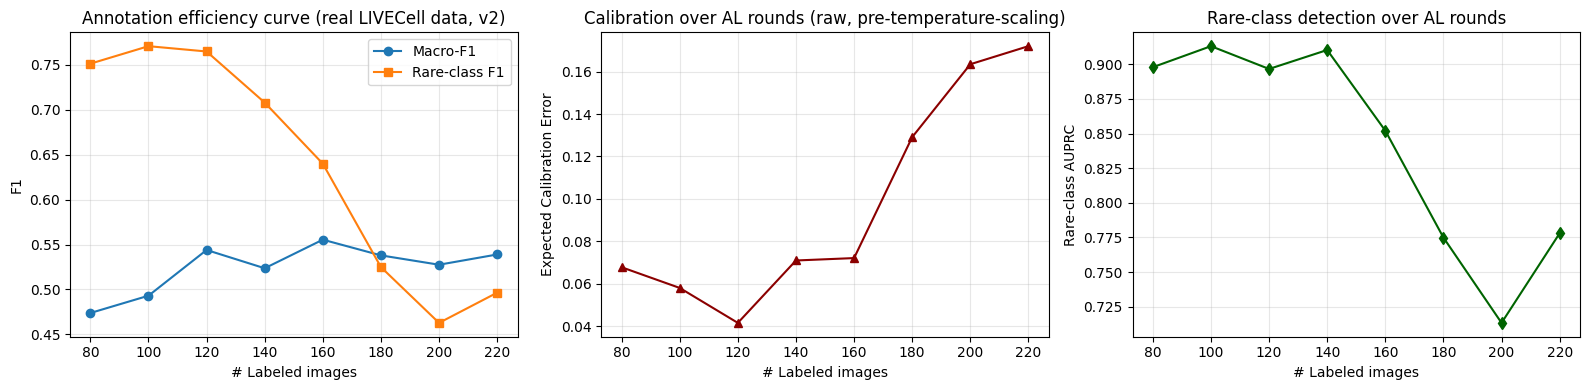

Saved plot to /content/drive/MyDrive/cse754/outputs/phase2_crossbatch/annotation_efficiency_curve.png


In [ ]:

n_labeled_hist = [r['n_labeled'] for r in results_log]
macro_f1_hist = [r['test']['macro_f1'] for r in results_log]
rare_f1_hist = [r['test']['rare_class_f1'] for r in results_log]
ece_hist = [r['test']['ece'] for r in results_log]
auprc_hist = [r['test']['rare_auprc'] for r in results_log]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(n_labeled_hist, macro_f1_hist, marker='o', label='Macro-F1')
axes[0].plot(n_labeled_hist, rare_f1_hist, marker='s', label='Rare-class F1')
axes[0].set_xlabel('# Labeled images')
axes[0].set_ylabel('F1')
axes[0].set_title('Annotation efficiency curve (real LIVECell data, v2)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(n_labeled_hist, ece_hist, marker='^', color='darkred')
axes[1].set_xlabel('# Labeled images')
axes[1].set_ylabel('Expected Calibration Error')
axes[1].set_title('Calibration over AL rounds (raw, pre-temperature-scaling)')
axes[1].grid(alpha=0.3)

axes[2].plot(n_labeled_hist, auprc_hist, marker='d', color='darkgreen')
axes[2].set_xlabel('# Labeled images')
axes[2].set_ylabel('Rare-class AUPRC')
axes[2].set_title('Rare-class detection over AL rounds')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(PHASE2_REAL_DIR, 'annotation_efficiency_curve.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print('Saved plot to', plot_path)


## 15. Acquisition-strategy comparison — round-0 snapshot (recap) + current pool

Unchanged from v1.

In [ ]:

print('=== Round-0 snapshot (the fair comparison; use this one) ===')
if strategy_comparison_snapshot is not None:
    print('(scores were computed at round 0; see printed table above in the AL loop output)')
else:
    print('No snapshot was captured (e.g. the pool was already empty at round 0).')

print()
print('=== Current pool (reference only -- likely partially/fully depleted of rare class) ===')
_ = compare_acquisition_strategies(model, train_pool, unlabeled_idx, labeled_idx, cfg, label='(current pool)')


=== Round-0 snapshot (the fair comparison; use this one) ===
(scores were computed at round 0; see printed table above in the AL loop output)

=== Current pool (reference only -- likely partially/fully depleted of rare class) ===
Acquisition-strategy comparison (current pool) | unlabeled pool=2595 | rare-class available=3
strategy                  rare% in top-B
random                              0.0%
entropy                             0.0%
margin                              0.0%
bald                                0.0%
class_balanced_bald                 0.0%


## 16. Post-hoc temperature-scaling calibration (NEW)

The proposal's calibration check (Slide 25) says to compute ECE each round and fall
back to a better-calibrated estimate if MC-Dropout undercovers. v1's test ECE got
roughly 10x worse over the run (0.02 → 0.25) as the model overfit — exactly the
miscalibration case that check is meant to catch. Section 9's early stopping should
reduce that overfitting directly; this section adds the complementary standard fix for
any *remaining* softmax overconfidence: fit one scalar temperature `T` on the
validation set (minimizing NLL), then rescale the final model's test-set predictive
distribution by it. `T > 1` flattens (reduces) overconfidence; `T < 1` would sharpen
it if the model were underconfident instead.

Temperature scaling only rescales confidence, not the predicted class, so `macro_f1` /
`rare_class_f1` / `balanced_accuracy` are unaffected — only `ece` (and, to a lesser
extent, `rare_auprc`, since it depends on the model's raw class-probability estimate,
not just its argmax) can change.

In [ ]:

def apply_temperature(mean_probs: np.ndarray, T: float) -> np.ndarray:
    eps = 1e-8
    logits = np.log(np.clip(mean_probs, eps, 1.0))
    scaled_logits = logits / T
    scaled_logits = scaled_logits - scaled_logits.max(axis=1, keepdims=True)  # numerical stability
    exp = np.exp(scaled_logits)
    return exp / exp.sum(axis=1, keepdims=True)


def fit_temperature(mean_probs: np.ndarray, labels: np.ndarray, T_grid=None):
    if T_grid is None:
        T_grid = np.linspace(0.5, 4.0, 36)
    eps = 1e-8
    best_T, best_nll = 1.0, float('inf')
    for T in T_grid:
        scaled = apply_temperature(mean_probs, T)
        nll = -np.mean(np.log(np.clip(scaled[np.arange(len(labels)), labels], eps, 1.0)))
        if nll < best_nll:
            best_nll, best_T = float(nll), float(T)
    return best_T, best_nll


@torch.no_grad()
def get_mean_probs_and_labels(model, dataset, indices, cfg: Config, T_eval: int = 20):
    loader = make_loader(dataset, indices, cfg.batch_size, shuffle=False)
    labels = get_labels(dataset, indices)
    mc_probs = mc_dropout_predict(model, loader, T=T_eval, device=device)
    return mc_probs.mean(axis=0), labels


val_mean_probs, val_labels_arr = get_mean_probs_and_labels(model, val_set, val_indices, cfg)
test_mean_probs, test_labels_arr = get_mean_probs_and_labels(model, test_set, test_indices, cfg)

fitted_T, val_nll_at_T = fit_temperature(val_mean_probs, val_labels_arr)
test_probs_calibrated = apply_temperature(test_mean_probs, fitted_T)

raw_test_ece = expected_calibration_error(test_mean_probs, test_labels_arr)
calibrated_test_ece = expected_calibration_error(test_probs_calibrated, test_labels_arr)

raw_test_preds = test_mean_probs.argmax(axis=1)
raw_test_macro_f1 = f1_score(test_labels_arr, raw_test_preds, average='macro', zero_division=0)

rare_binary_true = (test_labels_arr == cfg.rare_class_idx).astype(int)
raw_rare_auprc = average_precision_score(rare_binary_true, test_mean_probs[:, cfg.rare_class_idx]) \
    if rare_binary_true.sum() > 0 else float('nan')
calibrated_rare_auprc = average_precision_score(rare_binary_true, test_probs_calibrated[:, cfg.rare_class_idx]) \
    if rare_binary_true.sum() > 0 else float('nan')

print(f'Fitted temperature (on validation set): T = {fitted_T:.3f}')
print(f'Test macro-F1 (unaffected by temperature scaling): {raw_test_macro_f1:.4f}')
print(f'Test ECE          before calibration: {raw_test_ece:.4f}')
print(f'Test ECE          after  calibration: {calibrated_test_ece:.4f}')
print(f'Test rare-AUPRC   before calibration: {raw_rare_auprc:.4f}')
print(f'Test rare-AUPRC   after  calibration: {calibrated_rare_auprc:.4f}')

calibration_summary = {
    'fitted_temperature': fitted_T,
    'val_nll_at_fitted_T': val_nll_at_T,
    'test_macro_f1': float(raw_test_macro_f1),
    'test_ece_raw': raw_test_ece,
    'test_ece_calibrated': calibrated_test_ece,
    'test_rare_auprc_raw': float(raw_rare_auprc),
    'test_rare_auprc_calibrated': float(calibrated_rare_auprc),
}
with open(os.path.join(PHASE2_REAL_DIR, 'calibration_summary.json'), 'w') as f:
    json.dump(calibration_summary, f, indent=2)
print('Saved calibration summary to', os.path.join(PHASE2_REAL_DIR, 'calibration_summary.json'))


Fitted temperature (on validation set): T = 1.600
Test macro-F1 (unaffected by temperature scaling): 0.5313
Test ECE          before calibration: 0.1717
Test ECE          after  calibration: 0.0528
Test rare-AUPRC   before calibration: 0.7894
Test rare-AUPRC   after  calibration: 0.8130
Saved calibration summary to /content/drive/MyDrive/cse754/outputs/phase2_crossbatch/calibration_summary.json


## 17. Save final model checkpoint to Drive

In [ ]:

final_ckpt_path = os.path.join(CKPT_DIR, 'rare_cell_model_crossbatch_final.pt')
torch.save({
    'model_state_dict': model.state_dict(),
    'config': cfg.__dict__,
    'labeled_idx': labeled_idx,
    'results_log': results_log,
    'calibration_summary': calibration_summary,
}, final_ckpt_path)
print('Saved checkpoint to', final_ckpt_path)


Saved checkpoint to /content/drive/MyDrive/cse754/outputs/checkpoints/rare_cell_model_crossbatch_final.pt


## Notes / next steps

- **Compare this run's `al_results_log.json` directly against v1's**
  (`outputs/phase2_real/al_results_log.json`). The thing to check specifically: does
  test ECE still blow up over rounds, or does early stopping + higher weight decay
  keep it flat/low this time? Does rare-class F1/AUPRC trend up now instead of down?
- **`calibration_summary.json`** tells you whether temperature scaling actually helped
  on top of the early-stopping fix — if `test_ece_calibrated` isn't meaningfully lower
  than `test_ece_raw`, that's evidence the early-stopping fix already resolved most of
  the miscalibration on its own, and temperature scaling is just confirming that
  rather than doing much additional work.
- **Two caveats carried over from v1, still true here**: this is a same-platform
  generalization test (not cross-platform), and BV2's rarity in the training pool is
  constructed (only 15 crops sampled), not a natural property of LIVECell. State both
  plainly wherever these results are reported.
